# Extraction & Plotting Notebook — SSDB Maser (N = 1)

Reproduction of Li, Kim, Agarwal & Scully, *PRA 96, 063806 (2017)*.

This notebook **does not run any QuTiP simulation**. It only:
1. Reconstructs the `.npz` filename from the settings below (must match the generator script).
2. Loads the cached data.
3. Cross-checks saved metadata against local settings.
4. Prints summary diagnostics (thresholds, $g^{(2)}(0)$, photon statistics).
5. Reproduces Fig. 2 and Fig. 3 style plots from the paper, plus extra diagnostics.

Run the generator script first if the `.npz` file does not exist yet.

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

print("Current working directory:", os.getcwd())

Current working directory: /Users/gourabbhanja/Downloads


## 1. Settings

These must match the settings used in the generator script — they are only used to reconstruct the `.npz` filename.

In [40]:
kappa = 1.0
g = 14.0 * kappa
gamma_h = 32.0 * kappa
gamma_c = 32.0 * kappa
nc = 0.05
n_max = 30

nh_values = np.linspace(1e-3, 9.0, 60)
nh_points = np.array([0.17, 0.507, 2.629, 9.0])

data_folder = "data"
output_folder = "figures"
os.makedirs(output_folder, exist_ok=True)




## 2. Load data

In [41]:
import os
import glob
import numpy as np

# --------------------------------------------------------------
# Robust file locator: searches multiple likely locations
# --------------------------------------------------------------

candidate_name = "cavity_maser_N1.npz"

search_dirs = [
    os.getcwd(),                                      # current working directory
    os.path.join(os.getcwd(), "data"),                 # ./data (generator script default)
    os.path.expanduser("~/Downloads"),                 # Downloads folder
    os.path.expanduser("~"),                           # home directory
]

filename = None
for d in search_dirs:
    candidate_path = os.path.join(d, candidate_name)
    if os.path.exists(candidate_path):
        filename = candidate_path
        break

if filename is None:
    print("File NOT found in any of the expected locations:")
    for d in search_dirs:
        print(f"  - {os.path.join(d, candidate_name)}")

    print("\n--- Searching for ANY .npz files nearby, to help you locate it ---")
    for d in search_dirs:
        if os.path.isdir(d):
            npz_files = glob.glob(os.path.join(d, "*.npz"))
            if npz_files:
                print(f"\nFound in {d}:")
                for f in npz_files:
                    print(f"    {os.path.basename(f)}")

    raise FileNotFoundError(
        f"\nCould not find '{candidate_name}'.\n"
        "Possible causes:\n"
        "  1. The generator script was never run (or crashed before saving).\n"
        "  2. It saved under an auto-generated name in a 'data/' folder\n"
        "     (see make_filename() in the generator script) instead of\n"
        "     'cavity_maserN1.npz'.\n"
        "  3. The file was moved/renamed.\n\n"
        "Fix: either (a) run the generator script first, or (b) set 'filename'\n"
        "manually below to the exact path of the .npz file found above, e.g.:\n"
        "    filename = '/Users/gourabbhanja/Downloads/SSDB_N1_..._nmax30.npz'"
    )

print(f"Found data file: {filename}")
data = np.load(filename)

nh_values_l     = data["nh_values"]
G_over_kappa    = data["G_over_kappa"]
pop_g           = data["pop_g"]
pop_1           = data["pop_1"]
pop_2           = data["pop_2"]
navg_numeric    = data["navg_numeric"]
navg_analytic   = data["navg_analytic"]
g2_numeric      = data["g2_numeric"]
var_analytic    = data["var_analytic"]

nh_points_l     = data["nh_points"]
Pn_num_arr      = data["Pn_num_arr"]
Pn_an_arr       = data["Pn_an_arr"]
navg_fig3       = data["navg_fig3"]
g2_fig3         = data["g2_fig3"]
Wigner_arr      = data["Wigner_arr"]
xvec            = data["xvec"]

thresholds      = data["thresholds"]

kappa_saved   = float(data["kappa"])
g_saved       = float(data["g"])
gamma_h_saved = float(data["gamma_h"])
gamma_c_saved = float(data["gamma_c"])
nc_saved      = float(data["nc"])
n_max_saved   = int(data["n_max"])

print("Data loaded successfully.")
print("Arrays available:", list(data.keys()))

Found data file: /Users/gourabbhanja/Downloads/cavity_maser_N1.npz
Data loaded successfully.
Arrays available: ['nh_values', 'G_over_kappa', 'pop_g', 'pop_1', 'pop_2', 'navg_numeric', 'navg_analytic', 'g2_numeric', 'var_analytic', 'nh_points', 'Pn_num_arr', 'Pn_an_arr', 'navg_fig3', 'g2_fig3', 'Wigner_arr', 'xvec', 'thresholds', 'kappa', 'g', 'gamma_h', 'gamma_c', 'nc', 'n_max']


## 3. Metadata cross-check

Confirms the parameters stored inside the `.npz` match the local settings — catches stale-cache bugs if a parameter was changed in one script but not the other.

In [42]:
print("--- Metadata check (saved vs. local settings) ---")
all_ok = True
for name, saved, local in [
    ("kappa", kappa_saved, kappa),
    ("g", g_saved, g),
    ("gamma_h", gamma_h_saved, gamma_h),
    ("gamma_c", gamma_c_saved, gamma_c),
    ("nc", nc_saved, nc),
    ("n_max", n_max_saved, n_max),
]:
    ok = np.isclose(saved, local)
    all_ok &= ok
    flag = "OK" if ok else "MISMATCH!"
    print(f"  {name:8s}: saved={saved:<10} local={local:<10} [{flag}]")

if not all_ok:
    print("\nWARNING: one or more parameters differ between the cached file and "
          "the local settings in this notebook. Results below may not correspond "
          "to the settings printed in Section 1.")
else:
    print("\nAll metadata consistent.")

--- Metadata check (saved vs. local settings) ---
  kappa   : saved=1.0        local=1.0        [OK]
  g       : saved=14.0       local=14.0       [OK]
  gamma_h : saved=32.0       local=32.0       [OK]
  gamma_c : saved=32.0       local=32.0       [OK]
  nc      : saved=0.05       local=0.05       [OK]
  n_max   : saved=30         local=30         [OK]

All metadata consistent.


## 4. Summary diagnostics

In [43]:
print("--- Lasing thresholds (G/kappa = 1) ---")
print("  n_h =", thresholds)

if len(thresholds) == 2:
    print(f"\n  Below threshold 1 (n_h < {thresholds[0]:.4f}): thermal light")
    print(f"  Above threshold, lasing regime: {thresholds[0]:.4f} < n_h < {thresholds[1]:.4f}")
    print(f"  Above threshold 2 (n_h > {thresholds[1]:.4f}): thermal light again (double-threshold behavior)")

--- Lasing thresholds (G/kappa = 1) ---
  n_h = [0.18719715 8.64652378]

  Below threshold 1 (n_h < 0.1872): thermal light
  Above threshold, lasing regime: 0.1872 < n_h < 8.6465
  Above threshold 2 (n_h > 8.6465): thermal light again (double-threshold behavior)


In [44]:
print("--- Fig. 3 sample points diagnostics ---")
n_range = np.arange(Pn_num_arr.shape[1])

for row, nh in enumerate(nh_points_l):
    navg_from_Pn_num = np.sum(n_range * Pn_num_arr[row])
    navg_from_Pn_an  = np.sum(n_range * Pn_an_arr[row])
    print(f"  n_h={nh:6.3f} | <n>_num={navg_fig3[row]:.4f} "
          f"(from Pn: {navg_from_Pn_num:.4f}) | "
          f"<n>_analytic(fromPn)={navg_from_Pn_an:.4f} | "
          f"g2(0)_num={g2_fig3[row]:.3f}")

--- Fig. 3 sample points diagnostics ---
  n_h= 0.170 | <n>_num=0.9068 (from Pn: 0.9068) | <n>_analytic(fromPn)=0.9070 | g2(0)_num=1.287
  n_h= 0.507 | <n>_num=2.4162 (from Pn: 2.4162) | <n>_analytic(fromPn)=2.4197 | g2(0)_num=1.162
  n_h= 2.629 | <n>_num=4.3861 (from Pn: 4.3861) | <n>_analytic(fromPn)=4.3907 | g2(0)_num=1.133
  n_h= 9.000 | <n>_num=2.2231 (from Pn: 2.2231) | <n>_analytic(fromPn)=2.2554 | g2(0)_num=1.417


In [45]:
print("--- Photon statistics: variance/mean ratio (analytical, full sweep) ---")

ratio_var_mean = np.divide(
    var_analytic, navg_analytic,
    out=np.full_like(var_analytic, np.nan),
    where=navg_analytic > 1e-8
)

above_thr_mask = G_over_kappa >= 1.0
if np.any(above_thr_mask):
    print(f"  Above threshold range: n_h in "
          f"[{nh_values_l[above_thr_mask].min():.3f}, "
          f"{nh_values_l[above_thr_mask].max():.3f}]")
    print(f"  Mean variance/mean ratio above threshold: "
          f"{np.nanmean(ratio_var_mean[above_thr_mask]):.3f} "
          f"(>1 => super-Poissonian, =1 => Poissonian)")
else:
    print("  No points above threshold in this sweep.")

--- Photon statistics: variance/mean ratio (analytical, full sweep) ---
  Above threshold range: n_h in [0.306, 8.542]
  Mean variance/mean ratio above threshold: 1.850 (>1 => super-Poissonian, =1 => Poissonian)


## 5. Plot: Fig. 2 style — Gain, populations, cavity photon number

Saved: figures/Li2017_Fig2_reproduction.png


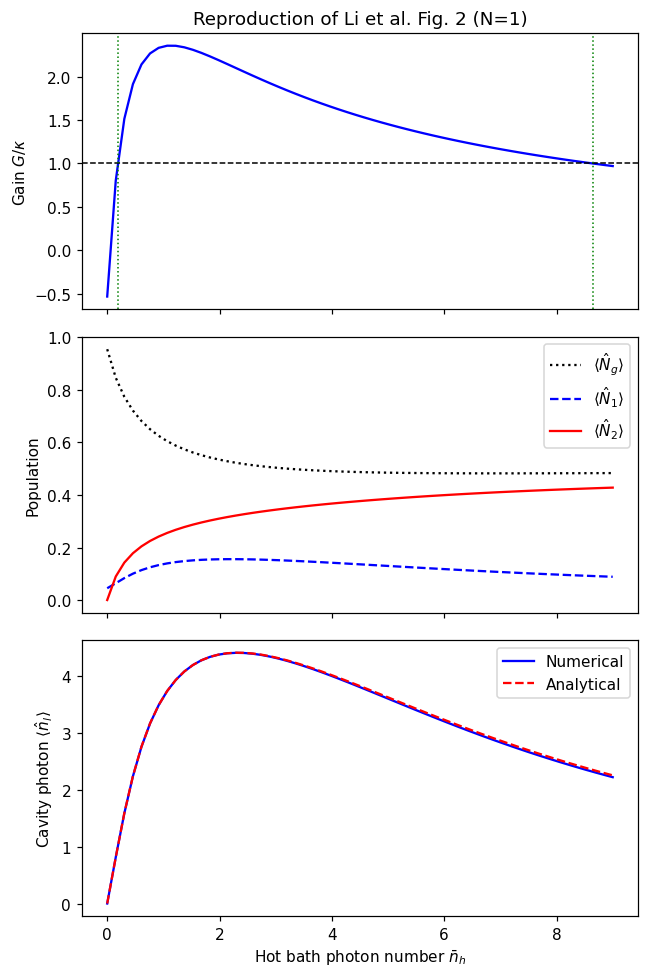

In [46]:
fig, axes = plt.subplots(3, 1, figsize=(6, 9), sharex=True)

axes[0].plot(nh_values_l, G_over_kappa, 'b-')
axes[0].axhline(1.0, color='k', ls='--', lw=1)
for th in thresholds:
    axes[0].axvline(th, color='g', ls=':', lw=1)
axes[0].set_ylabel(r'Gain $G/\kappa$')
axes[0].set_title('Reproduction of Li et al. Fig. 2 (N=1)')

axes[1].plot(nh_values_l, pop_g, 'k:', label=r'$\langle \hat N_g\rangle$')
axes[1].plot(nh_values_l, pop_1, 'b--', label=r'$\langle \hat N_1\rangle$')
axes[1].plot(nh_values_l, pop_2, 'r-', label=r'$\langle \hat N_2\rangle$')
axes[1].set_ylabel('Population')
axes[1].legend()

axes[2].plot(nh_values_l, navg_numeric, 'b-', label='Numerical')
axes[2].plot(nh_values_l, navg_analytic, 'r--', label='Analytical')
axes[2].set_ylabel(r'Cavity photon $\langle \hat n_l\rangle$')
axes[2].set_xlabel(r'Hot bath photon number $\bar n_h$')
axes[2].legend()

plt.tight_layout()
fig2_path = os.path.join(output_folder, "Li2017_Fig2_reproduction.png")
plt.savefig(fig2_path, dpi=150)
print(f"Saved: {fig2_path}")
plt.show()

## 6. Plot: $g^{(2)}(0)$ vs $\bar n_h$ (extra diagnostic)

Saved: figures/Li2017_g2_vs_nh.png


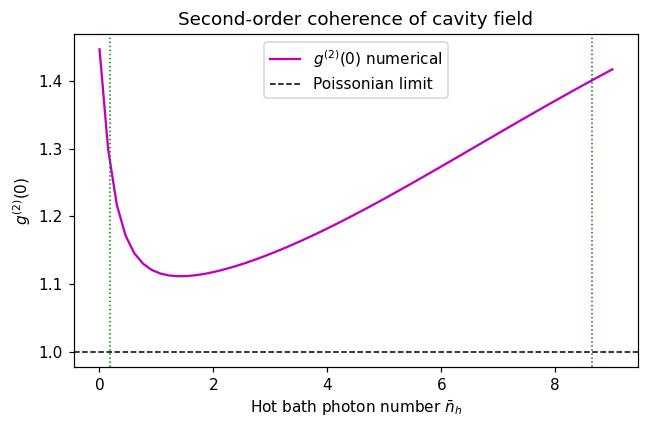

In [47]:
fig_g2, ax_g2 = plt.subplots(figsize=(6, 4))
ax_g2.plot(nh_values_l, g2_numeric, 'm-', label=r'$g^{(2)}(0)$ numerical')
ax_g2.axhline(1.0, color='k', ls='--', lw=1, label='Poissonian limit')
for th in thresholds:
    ax_g2.axvline(th, color='g', ls=':', lw=1)
ax_g2.set_xlabel(r'Hot bath photon number $\bar n_h$')
ax_g2.set_ylabel(r'$g^{(2)}(0)$')
ax_g2.set_title('Second-order coherence of cavity field')
ax_g2.legend()
plt.tight_layout()
g2_path = os.path.join(output_folder, "Li2017_g2_vs_nh.png")
plt.savefig(g2_path, dpi=150)
print(f"Saved: {g2_path}")
plt.show()

## 7. Plot: Fig. 3 style — photon number distributions & Wigner functions

Saved: figures/Li2017_Fig3_reproduction.png


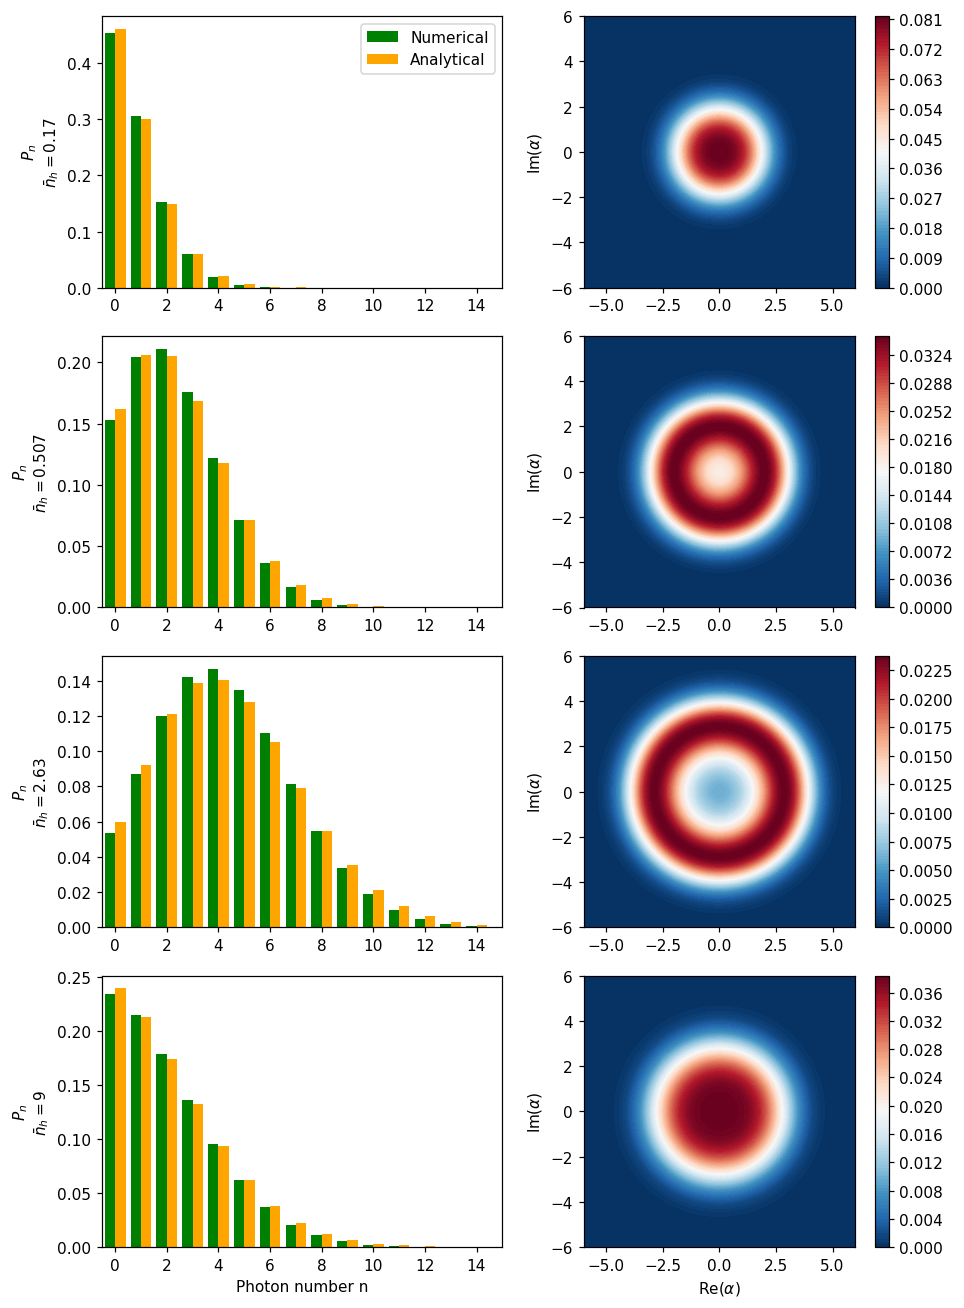

In [48]:
fig3, axes3 = plt.subplots(len(nh_points_l), 2, figsize=(9, 12))

for row, nh in enumerate(nh_points_l):
    width = 0.4
    axes3[row, 0].bar(n_range - width/2, Pn_num_arr[row], width=width,
                       color='green', label='Numerical')
    axes3[row, 0].bar(n_range + width/2, Pn_an_arr[row], width=width,
                       color='orange', label='Analytical')
    axes3[row, 0].set_xlim(-0.5, 15)
    axes3[row, 0].set_ylabel(f"$P_n$\n" + r"$\bar n_h=$" + f"{nh:.3g}")
    if row == 0:
        axes3[row, 0].legend()
    if row == len(nh_points_l) - 1:
        axes3[row, 0].set_xlabel("Photon number n")

    im = axes3[row, 1].contourf(xvec, xvec, Wigner_arr[row], 100, cmap='RdBu_r')
    axes3[row, 1].set_aspect('equal')
    if row == len(nh_points_l) - 1:
        axes3[row, 1].set_xlabel("Re($\\alpha$)")
    axes3[row, 1].set_ylabel("Im($\\alpha$)")
    fig3.colorbar(im, ax=axes3[row, 1])

plt.tight_layout()
fig3_path = os.path.join(output_folder, "Li2017_Fig3_reproduction.png")
plt.savefig(fig3_path, dpi=150)
print(f"Saved: {fig3_path}")
plt.show()

## 8. Extra: zoomed-in view near each threshold

Useful for visually confirming the exact location of the two critical points where $G/\kappa$ crosses 1.

Saved: figures/Li2017_threshold_zoom.png


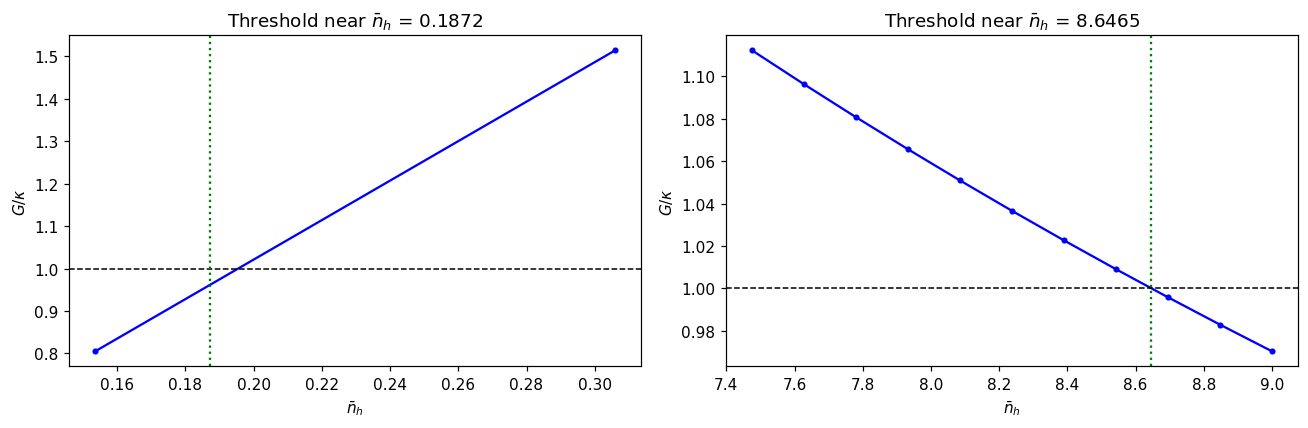

In [49]:
if len(thresholds) > 0:
    fig_zoom, axes_zoom = plt.subplots(1, len(thresholds), figsize=(6 * len(thresholds), 4))
    if len(thresholds) == 1:
        axes_zoom = [axes_zoom]

    for ax, th in zip(axes_zoom, thresholds):
        window = 0.15 * max(th, 1.0)
        mask = (nh_values_l > th - window) & (nh_values_l < th + window)
        ax.plot(nh_values_l[mask], G_over_kappa[mask], 'b.-')
        ax.axhline(1.0, color='k', ls='--', lw=1)
        ax.axvline(th, color='g', ls=':', lw=1.5)
        ax.set_title(f"Threshold near $\\bar n_h$ = {th:.4f}")
        ax.set_xlabel(r'$\bar n_h$')
        ax.set_ylabel(r'$G/\kappa$')

    plt.tight_layout()
    zoom_path = os.path.join(output_folder, "Li2017_threshold_zoom.png")
    plt.savefig(zoom_path, dpi=150)
    print(f"Saved: {zoom_path}")
    plt.show()
else:
    print("No thresholds found in this sweep range.")

## 9. Extra: variance-to-mean ratio across the sweep (photon statistics)

Shows where the field is sub-Poissonian, Poissonian, or super-Poissonian (Eq. 20–21 of Li et al.).

Saved: figures/Li2017_variance_ratio.png


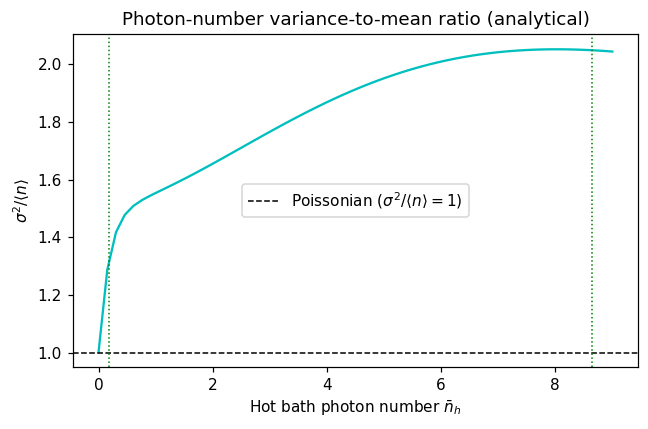

In [50]:
fig_stat, ax_stat = plt.subplots(figsize=(6, 4))
ax_stat.plot(nh_values_l, ratio_var_mean, 'c-')
ax_stat.axhline(1.0, color='k', ls='--', lw=1, label='Poissonian ($\\sigma^2/\\langle n\\rangle = 1$)')
for th in thresholds:
    ax_stat.axvline(th, color='g', ls=':', lw=1)
ax_stat.set_xlabel(r'Hot bath photon number $\bar n_h$')
ax_stat.set_ylabel(r'$\sigma^2 / \langle n \rangle$')
ax_stat.set_title('Photon-number variance-to-mean ratio (analytical)')
ax_stat.legend()
plt.tight_layout()
stat_path = os.path.join(output_folder, "Li2017_variance_ratio.png")
plt.savefig(stat_path, dpi=150)
print(f"Saved: {stat_path}")
plt.show()

## 10. Wrap-up

In [51]:
print("Extraction and plotting completed successfully.")
print(f"All figures saved under: {os.path.abspath(output_folder)}")

Extraction and plotting completed successfully.
All figures saved under: /Users/gourabbhanja/Downloads/figures
